# QMCPy Performance Optimizations Demo

Sou-Cheng T. Choi

Illinois Institute of Technology and SouLab LLC.

Modification date: 9/23/2026

Creation date: 8/14/2026

For reproducibility, this notebook was run with:
- Python 3.13.13, NumPy 2.5.0 [1], SciPy 1.17.1 [2], QMCPy 2.5 [4], PyTorch 2.12.1 [5] (for the multitask kernel section), qmctoolscl 1.2.3 (for Section 9; the fix proposed there targets [QMCToolsCL](https://github.com/QMCSoftware/QMCToolsCL))
- OS: macOS 15.6.1

This notebook details targeted optimizations for QMCPy's internals, significantly boosting performance. We focused on three key areas: replacing generic `scipy.stats` calls with direct `scipy.special` C-level functions; swapping `np.einsum` for `@`/`matmul` to ensure routing through BLAS's `GEMM` kernel; and replacing nested Python loops with NumPy broadcasting.

**Why these improvements are so fast:**

*   **Direct Calls:** The old `scipy.stats` methods incurred overhead (validation, handling) that is bypassed by calling the underlying `scipy.special` routines directly.
*   **BLAS Routing:** `np.einsum` is a general interpreter. By using `@`/`matmul`, we guarantee the calculation routes through BLAS's highly optimized `GEMM` kernel, potentially yielding a 10-50x speedup for matrix multiplications.
*   **Vectorization:** A nested Python loop executes $n^2$ individual Python operations. NumPy broadcasting performs the same $n^2$ work using compiled, vectorized C loops, which is dramatically faster.

Each section below compares a "legacy" function (the old approach) against the optimized QMCPy call, reporting the speedup. Please note that all outputs were verified to be numerically identical (up to floating-point rounding) before timing.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/performance_optimizations_demo.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import t as t_dist
from scipy.special import ndtri, ndtr, stdtrit

from qmcpy import BrownianMotion, DigitalNetB2, Halton

rng = np.random.default_rng(7)

results_table = []

def report(name, t_old, s_old, t_new, s_new, max_diff):
    assert max_diff < 1e-8, f'{name}: old and new results diverge (max diff {max_diff:.2e})'
    speedup = t_old / t_new
    results_table.append((name, t_old, s_old, t_new, s_new, speedup, max_diff))
    print(f'{name}')
    print(f'  old: {t_old:.2e} ± {s_old:.2e} s   new: {t_new:.2e} ± {s_new:.2e} s   speedup: {speedup:.1f}x   max diff: {max_diff:.2e}')

def compare(name, legacy_fn, fast_fn):
    """Time legacy_fn/fast_fn with IPython's %timeit (auto-calibrated loop count, 7
    repeats -- as in gbm_demo's `%timeit -n -r`), verify they agree, and report()."""
    r_old, r_new = legacy_fn(), fast_fn()
    old_timing = %timeit -r 7 -o legacy_fn()
    new_timing = %timeit -r 7 -o fast_fn()
    report(name, old_timing.average, old_timing.stdev, new_timing.average, new_timing.stdev, np.abs(r_old - r_new).max())

## 1. Gaussian PCA Transform (`true_measure/gaussian.py`)

*(Note: This change landed on develop via PR #585. Keeping this here for context.)*

This is the code path used by default (`decomp_type="PCA"`) by `Gaussian`, `BrownianMotion`, and `GeometricBrownianMotion` . It is exercised any time `demos/GBM/gbm_demo.ipynb` samples GBM paths with a Sobol', Lattice, or Halton sampler. `A` below stands in for the cached PCA factor matrix.

In [3]:
n, d = 2**14, 252
x = rng.random((n, d))
A = rng.standard_normal((d, d))
mu = np.zeros(d)

def legacy_gaussian_transform():
    return mu + np.einsum('...ij,kj->...ik', norm.ppf(x), A)

def fast_gaussian_transform():
    out = ndtri(x) @ A.T
    out += mu
    return out

compare('1. Gaussian PCA transform (gaussian.py)', legacy_gaussian_transform, fast_gaussian_transform)


245 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
35.5 ms ± 757 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1. Gaussian PCA transform (gaussian.py)
  old: 2.45e-01 ± 2.63e-03 s   new: 3.55e-02 ± 7.57e-04 s   speedup: 6.9x   max diff: 1.21e-13


## 2. Brownian Bridge Transform (`true_measure/brownian_motion.py`)

This section covers two benchmarks: the full transform (2a) and, further below, an isolated comparison of just the loop-vectorization change (2b).

**(2a) Full Brownian bridge transform:** this optimizes the `_bridge_transform` function, used when `decomp_type="BrownianBridge"`.

We have significantly improved performance by replacing the explicit Python loop with vectorized NumPy operations. This reduces loop iterations to $O(\log d)$, even though the total numerical work remains $O(d)$. This optimization ensures the output remains bit-identical to the original calculation.

Crucially, we have addressed previous performance regressions. The function now intelligently checks the size of the bisection levels and automatically falls back to the plain scalar update when batching is inefficient (such as for small dimensions or degenerate grids). This ensures that performance matches the pre-optimization cost in edge cases while maintaining substantial speed gains for genuinely large, tree-shaped dimensions.

In [4]:
d, n_paths = 256, 2**12
bm = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type='BrownianBridge')
u = rng.random((n_paths, d))

def legacy_bridge_transform():
    z = norm.ppf(u)
    w = bm._bridge_transform(z)
    paths = bm.drift_time_vec_plus_init + np.sqrt(bm.diffusion) * w
    return paths[..., bm._output_order]

def fast_bridge_transform():
    return bm._transform(u)

compare('2a. Brownian bridge transform (brownian_motion.py)', legacy_bridge_transform, fast_bridge_transform)


21.6 ms ± 631 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
14.9 ms ± 230 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2a. Brownian bridge transform (brownian_motion.py)
  old: 2.16e-02 ± 6.31e-04 s   new: 1.49e-02 ± 2.30e-04 s   speedup: 1.5x   max diff: 0.00e+00


**(2b) Isolating the loop-vectorization from the `ndtri` swap:** the comparison above holds the bridge construction fixed and only swaps `norm.ppf` for `ndtri`, so it doesn't show the level-batching change on its own; both sides call the same (already-optimized) `_bridge_transform`. Here's the original per-dimension Python loop against the current level-batched version directly, both fed the same pre-computed `z`, isolating just that change.

In [5]:
def legacy_bridge_loop(z):
    left, right = bm._bridge_left, bm._bridge_right
    a, b, w = bm._bridge_a, bm._bridge_b, bm._bridge_w
    paths = np.empty(z.shape[:-1] + (bm.d,))
    for j in range(bm.d):
        paths[..., j] = w[j] * z[..., j]
        if left[j] >= 0:
            paths[..., j] += a[j] * paths[..., left[j]]
        if right[j] >= 0:
            paths[..., j] += b[j] * paths[..., right[j]]
    return paths[..., bm._increasing_order]

z = ndtri(u)

def legacy_bridge_loop_call():
    return legacy_bridge_loop(z)

def fast_bridge_level_batched():
    return bm._bridge_transform(z)

compare('2b. Brownian bridge loop -> level-batched (brownian_motion.py)', legacy_bridge_loop_call, fast_bridge_level_batched)


12.2 ms ± 86.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.53 ms ± 129 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2b. Brownian bridge loop -> level-batched (brownian_motion.py)
  old: 1.22e-02 ± 8.63e-05 s   new: 5.53e-03 ± 1.29e-04 s   speedup: 2.2x   max diff: 0.00e+00


## 3. Gaussian Copula Density (`true_measure/gaussian_copula.py`)

Used by `GaussianCopula._weight()`, showcased in `demos/copula_examples.ipynb`. This combines *both* techniques: `norm.ppf` -> `ndtri`, and a 3-operand quadratic-form `einsum` -> a matmul-then-reduce.

In [6]:
d, n = 40, 2**14
M = rng.standard_normal((d, d)); M = M @ M.T  # stand-in for corr_inv_minus_eye
u = rng.random((n, d))
logdet = 0.0

def legacy_copula_quad():
    z = norm.ppf(u)
    quad = np.einsum('...i,ij,...j->...', z, M, z)
    return -0.5 * logdet - 0.5 * quad

def fast_copula_quad():
    z = ndtri(u)
    quad = ((z @ M) * z).sum(-1)
    return -0.5 * logdet - 0.5 * quad

compare('3. Gaussian copula log-density (gaussian_copula.py)', legacy_copula_quad, fast_copula_quad)


38.3 ms ± 316 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
5.64 ms ± 69.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3. Gaussian copula log-density (gaussian_copula.py)
  old: 3.83e-02 ± 3.16e-04 s   new: 5.64e-03 ± 6.93e-05 s   speedup: 6.8x   max diff: 7.50e-12


## 4. Student-t Quantile (`true_measure/student_t.py`, `student_t_copula.py`)

The `StudentT` and `StudentTCopula` classes generate multivariate Student-t samples using a sequence of univariate conditional quantiles, which are typically computed with `scipy.stats.t.ppf`. While `scipy.special.stdtrit` serves as a direct alternative, please note that the argument order flips from `t.ppf(q, df)` to `stdtrit(df, q)`.

Unlike `ndtri`, `stdtrit` is not a simple closed-form transform; Cephes solves for it iteratively. Consequently, its compute cost grows with array size, increasingly dominating the fixed `rv_continuous` overhead we are removing. Therefore, the performance gain here is much more size-dependent than in Sections 1-3: it is substantial for a handful of values, but only modest for a full batch of QMC points.

In [7]:
df = 6.0
n_paths = 2**10
p = rng.random(n_paths)

def legacy_t_quantile():
    return t_dist.ppf(p, df=df)

def fast_t_quantile():
    return stdtrit(df, p)

compare('4. Student-t quantile (student_t_copula.py)', legacy_t_quantile, fast_t_quantile)


168 μs ± 673 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
139 μs ± 2.33 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
4. Student-t quantile (student_t_copula.py)
  old: 1.68e-04 ± 6.73e-07 s   new: 1.39e-04 ± 2.33e-06 s   speedup: 1.2x   max diff: 0.00e+00


## 5. GBM Covariance Matrix (`true_measure/geometric_brownian_motion.py`)

The `GeometricBrownianMotion.covariance_gbm` function builds the $n \times n$ covariance matrix once per instance. Previously, the code used a broadcasted formula for $n \le 200$, but for larger $n$, it fell back to slow, nested Python loops, which were commented as being for "memory efficiency."

We determined that this claim was incorrect: both code paths allocated the full $n \times n$ array, meaning the loop only introduced unnecessary runtime cost. We have removed the loop entirely, ensuring that the efficient broadcasted formula now runs for all values of $n$.

In [8]:
def legacy_gbm_covariance(t, S0_sq, mu, diffusion):
    n = len(t)
    cov_matrix = np.zeros((n, n))
    exp_mu_t = np.exp(mu * t)
    exp_diff_t = np.exp(diffusion * t)
    for i in range(n):
        cov_matrix[i, i] = S0_sq * exp_mu_t[i] ** 2 * (exp_diff_t[i] - 1)
        for j in range(i + 1, n):
            t_min_ij = min(t[i], t[j])
            cov_ij = S0_sq * exp_mu_t[i] * exp_mu_t[j] * (np.exp(diffusion * t_min_ij) - 1)
            cov_matrix[i, j] = cov_ij
            cov_matrix[j, i] = cov_ij
    return cov_matrix

def fast_gbm_covariance(t, S0_sq, mu, diffusion):
    t_sum = t[:, None] + t[None, :]
    t_min = np.minimum.outer(t, t)
    return S0_sq * np.exp(mu * t_sum) * (np.exp(diffusion * t_min) - 1)

n_steps = 252  # the default used throughout demos/GBM/gbm_demo.ipynb -- and >200, the old threshold
t = np.linspace(1 / n_steps, 1.0, n_steps)
S0_sq, mu, diffusion = 100.0**2, 0.05, 0.2**2

def legacy_gbm_cov_call():
    return legacy_gbm_covariance(t, S0_sq, mu, diffusion)

def fast_gbm_cov_call():
    return fast_gbm_covariance(t, S0_sq, mu, diffusion)

compare('5. GBM covariance matrix (geometric_brownian_motion.py)', legacy_gbm_cov_call, fast_gbm_cov_call)


13.3 ms ± 110 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
365 μs ± 7.54 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
5. GBM covariance matrix (geometric_brownian_motion.py)
  old: 1.33e-02 ± 1.10e-04 s   new: 3.65e-04 ± 7.54e-06 s   speedup: 36.3x   max diff: 1.71e-13


## 6. Multitask Kernel Matrix (`kernel/multitask_kernel.py`)

`KernelMultiTask.taskmat` builds a batched task-covariance matrix for multi-output/multi-fidelity Bayesian cubature. It previously used `einsum("...ij,...kj->...ik", ...)`; now it uses a batched `matmul`.

In [9]:
batch, num_tasks, rank = 2**10, 8, 8
factor = rng.standard_normal((batch, num_tasks, rank))

def legacy_taskmat():
    return np.einsum('...ij,...kj->...ik', factor, factor)

def fast_taskmat():
    return np.matmul(factor, np.swapaxes(factor, -1, -2))

compare('6. Multitask kernel taskmat (multitask_kernel.py)', legacy_taskmat, fast_taskmat)


354 μs ± 8.52 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
116 μs ± 491 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
6. Multitask kernel taskmat (multitask_kernel.py)
  old: 3.54e-04 ± 8.52e-06 s   new: 1.16e-04 ± 4.91e-07 s   speedup: 3.0x   max diff: 7.11e-15


## 7. Bayesian Logistic Regression Integrand (`integrand/bayesian_lr_coeffs.py`)

`BayesianLRCoeffs.g(x)` evaluates the log-likelihood integrand at each sampled coefficient vector; showcased in `demos/vectorized_qmc_bayes.ipynb`. The `einsum("...j,ij->...i", x, feature_array)` step is really `x @ feature_array.T`.

In [10]:
n, n_coeffs, n_obs = 2**14, 4, 205  # n_coeffs/n_obs match demos/vectorized_qmc_bayes.ipynb's Haberman-dataset setup
x = rng.standard_normal((n, n_coeffs))
feature_array = rng.standard_normal((n_obs, n_coeffs))

def legacy_bayesian_lr():
    return np.einsum('...j,ij->...i', x, feature_array)

def fast_bayesian_lr():
    return x @ feature_array.T

compare('7. Bayesian LR feature projection (bayesian_lr_coeffs.py)', legacy_bayesian_lr, fast_bayesian_lr)

9.3 ms ± 139 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
649 μs ± 9.52 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
7. Bayesian LR feature projection (bayesian_lr_coeffs.py)
  old: 9.30e-03 ± 1.39e-04 s   new: 6.49e-04 ± 9.52e-06 s   speedup: 14.3x   max diff: 3.55e-15


## 8. Black-Scholes Exact Price (`integrand/financial_option.py`)

The `FinancialOption.get_exact_value()` method prices European/Asian options using closed-form Black-Scholes formulas. This process requires only a handful of scalar `norm.cdf` evaluations per pricing request, which is a significant difference from calling it once per QMC sample.

This mechanism operates in a different regime than the Bayesian LR case in Section 7. While the overall workload is small either way, the entire cost here stems from the `norm.cdf`'s `rv_continuous` overhead (since there is no BLAS/vectorization to fall back on). Consequently, removing this overhead provides a performance gain of orders of magnitude, rather than merely reducing noise.

In [11]:
d1, d2 = 0.35, 0.15  # the two scalar log-moneyness (ln(S/K), roughly) terms in get_exact_value

def legacy_bs_cdf():
    return norm.cdf(d1) - norm.cdf(d2)

def fast_bs_cdf():
    return ndtr(d1) - ndtr(d2)

compare('8. Black-Scholes normal CDF (financial_option.py)', legacy_bs_cdf, fast_bs_cdf)


33.4 μs ± 1.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
125 ns ± 1.39 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
8. Black-Scholes normal CDF (financial_option.py)
  old: 3.34e-05 ± 1.30e-06 s   new: 1.25e-07 ± 1.39e-09 s   speedup: 266.5x   max diff: 0.00e+00


## 9. Halton Digital-Permutation Scrambling (`qmctoolscl` dependency)

Constructing a randomized `Halton(d, seed=...)` generator with the default `randomize="LMS DP"` draws a fresh random digit-permutation table for every (replication, dimension, digit) triple, via `qmctoolscl.gdn_get_digital_permutations` in QMCPy's separate low-level point-generation package ([`qmctoolscl`](https://github.com/QMCSoftware/QMCToolsCL), not `qmcpy` itself). The shipped implementation draws each permutation with its own `rng.permutation(b)` call inside a triple-nested Python loop, which dominates construction time -- e.g. ~90ms just to build a 250-dimensional Halton generator, before a single sample is drawn.

This is a *proposed* fix to `qmctoolscl` rather than a change already merged into `qmcpy`, so `legacy_*`/`fast_*` below are standalone reimplementations of the public, documented `qmctoolscl.gdn_get_digital_permutations` function rather than a call into current-vs-old `qmcpy` code. Otherwise it follows the exact same `compare()` pattern as Sections 1-8: NumPy's `Generator.permuted(x, axis=-1)` independently shuffles each row of an array along one axis using the *same* $O(b)$ Fisher-Yates algorithm as `rng.permutation(b)` internally -- just as one vectorized call per dimension instead of `tmax_new` separate Python-level calls per digit -- so old and new draw bit-identical permutations for the same seed. Verified both by the `max diff: 0.00e+00` below and against `qmctoolscl`'s own full doctest suite (no expected output needed updating there).

(A tempting alternative, `np.argsort(rng.random(...))`, also generates independent permutations, but it's $O(b\log b)$, not $O(b)$, and draws *different* values than the original loop. Once dimensions with large prime bases dominate it ends up *slower* than the original -- 12,377ms vs. the original 2,955ms for 32 replications of a 250-dimensional generator, in our testing -- so we didn't use it here.)

The speedup is workload-dependent, since Halton's bases are the first `d` primes and larger primes make the unavoidable $O(b)$ shuffle cost itself (not loop overhead) the bottleneck. This section covers two benchmarks to show that range concretely: a moderate, realistic case (9a) and, further below, a more extreme case (9b).

**(9a) A moderate, realistic case:** 20-dimensional Halton with 32 independent replications, a typical MLQMC/error-estimation setup mixing moderate-sized bases (up to the 20th prime, 71) with a moderate replication count.

In [12]:
def legacy_gdn_get_digital_permutations(r, d, tmax_new, r_b, bases):
    """Currently shipped qmctoolscl implementation."""
    rng = np.random.Generator(np.random.PCG64(7))
    bases_2d = np.atleast_2d(bases)
    bmax = int(bases_2d.max())
    perms = np.zeros((r, d, tmax_new, bmax), dtype=np.uint64)
    for l in range(r):
        l_b = l % r_b
        for j in range(d):
            b = int(bases_2d[l_b, j])
            for t in range(tmax_new):
                perms[l, j, t, :b] = rng.permutation(b)
    return perms

def fast_gdn_get_digital_permutations(r, d, tmax_new, r_b, bases):
    """Proposed fix: rng.permuted replaces the innermost (digit) loop."""
    rng = np.random.Generator(np.random.PCG64(7))
    bases_2d = np.atleast_2d(bases)
    bmax = int(bases_2d.max())
    perms = np.zeros((r, d, tmax_new, bmax), dtype=np.uint64)
    for l in range(r):
        l_b = l % r_b
        for j in range(d):
            b = int(bases_2d[l_b, j])
            tiled = np.broadcast_to(np.arange(b, dtype=np.uint64), (tmax_new, b))
            perms[l, j, :, :b] = rng.permuted(tiled, axis=-1)
    return perms

# 9a: 20-dimensional Halton with 32 independent replications -- a realistic MLQMC/error-estimation setup
halton_bases = Halton(20, seed=0, randomize='FALSE', warn=False).bases  # shape (1, 20): the first 20 primes
r_dim, d_dim, tmax_new_dim, r_b_dim = 32, 20, 63, 1

compare(
    '9a. Halton permutation, d=20 r=32',
    lambda: legacy_gdn_get_digital_permutations(r_dim, d_dim, tmax_new_dim, r_b_dim, halton_bases),
    lambda: fast_gdn_get_digital_permutations(r_dim, d_dim, tmax_new_dim, r_b_dim, halton_bases),
)

41.6 ms ± 146 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
9.81 ms ± 42.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
9a. Halton permutation, d=20 r=32
  old: 4.16e-02 ± 1.46e-04 s   new: 9.81e-03 ± 4.27e-05 s   speedup: 4.2x   max diff: 0.00e+00


**(9b) A more extreme case:** dropping to a low dimension (small bases, so the $O(b)$ shuffle itself is cheap) with many more replications than 9a (so the eliminated Python-level call count -- `r * d * tmax_new` calls in the original -- grows much larger relative to the work each call does) isolates the loop-overhead removal much more starkly.

In [13]:
# 9b: 5-dimensional Halton with 64 independent replications -- low dimension, many replications
halton_bases_lowd = Halton(5, seed=0, randomize='FALSE', warn=False).bases  # shape (1, 5): the first 5 primes
r_lowd, d_lowd, tmax_new_lowd, r_b_lowd = 64, 5, 63, 1

compare(
    '9b. Halton permutation, d=5 r=64',
    lambda: legacy_gdn_get_digital_permutations(r_lowd, d_lowd, tmax_new_lowd, r_b_lowd, halton_bases_lowd),
    lambda: fast_gdn_get_digital_permutations(r_lowd, d_lowd, tmax_new_lowd, r_b_lowd, halton_bases_lowd),
)

17.2 ms ± 89.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.44 ms ± 4.65 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
9b. Halton permutation, d=5 r=64
  old: 1.72e-02 ± 8.97e-05 s   new: 1.44e-03 ± 4.65e-06 s   speedup: 11.9x   max diff: 0.00e+00


## 10. Halton Prime-Table Constant (`discrete_distribution/digital_net_any_bases/digital_net_any_bases.py`)

`DigitalNetAnyBases.__init__` -- the base class behind `Halton`, so this runs on every `Halton(...)` construction -- built a 1000-entry array of primes from a hardcoded Python list literal every single time, even though the data never changes. We hoisted it to a module-level constant, `_ALL_PRIMES` (read-only, via `setflags(write=False)`), computed once when the module is first imported; `__init__` now does `self.all_primes = _ALL_PRIMES.copy()` -- still far cheaper than rebuilding from the list literal, but a real per-instance copy, not a bare alias. (An earlier version of this change aliased `_ALL_PRIMES` directly, which let one instance's mutation of `all_primes` silently corrupt every other instance; a reviewer caught it and it's now fixed and regression-tested in `test/test_dd_discrete_distribs.py::TestHalton::test_instances_do_not_share_prime_table`.)

This is a small, atomic change -- the array build is a tiny fraction of total `Halton` construction cost, which is otherwise dominated by the `qmctoolscl` scrambling work in Section 9 above -- but it's a real, unconditional saving on every single construction, so we isolate and measure it directly here rather than trying to attribute a sliver of a full `Halton(...)` call. Unlike Section 9, this fix is already merged into `qmcpy` itself, so it follows the standard `compare()` pattern with no caveats.

In [14]:
from qmcpy.discrete_distribution.digital_net_any_bases.digital_net_any_bases import _ALL_PRIMES

_primes_list = _ALL_PRIMES.tolist()  # the actual 1000-prime data qmcpy ships, extracted once here

def legacy_all_primes_rebuild():
    """Old qmcpy code: rebuilt this array from a literal on every DigitalNetAnyBases.__init__ call."""
    return np.array(_primes_list, dtype=np.uint64)

def fast_all_primes_lookup():
    """Current qmcpy code: copies the module-level constant, computed once at import time.
    (Not a bare alias -- aliasing let every instance share, and corrupt, one mutable array.)"""
    return _ALL_PRIMES.copy()

compare('10. Halton prime table', legacy_all_primes_rebuild, fast_all_primes_lookup)

15.5 μs ± 140 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
233 ns ± 5.19 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
10. Halton prime table
  old: 1.55e-05 ± 1.40e-07 s   new: 2.33e-07 ± 5.19e-09 s   speedup: 66.5x   max diff: 0.00e+00


## Summary

The table and chart below include each benchmark's relative standard deviation (% of the mean, from `n_trials` repeated timing trials). Faster calls tend to show a higher relative std than slower ones for the same reason on this shared machine: fixed-size system noise (scheduler jitter, memory allocation, GC) is roughly constant in absolute terms, so it eats up a bigger fraction of a smaller runtime. A high % next to a fast component (e.g. Section 8's broadcasted GBM covariance) reflects that noise floor, not an issue with the implementation.

In [15]:
summary_df = pd.DataFrame(
    results_table,
    columns=['Component', 'Old (s)', 'Old Std (s)', 'New (s)', 'New Std (s)', 'Speedup', 'Max Abs Diff'],
)
sorted_summary_df = summary_df.sort_values(by='Speedup', ascending=False)
sorted_summary_df.style.format({
    'Old (s)': '{:.2e}',
    'Old Std (s)': '{:.2e}',
    'New (s)': '{:.2e}',
    'New Std (s)': '{:.2e}',
    'Speedup': '{:.1f}x',
    'Max Abs Diff': '{:.2e}',
})

,Component,Old (s),Old Std (s),New (s),New Std (s),Speedup,Max Abs Diff
8,8. Black-Scholes normal CDF (financial_option.py),3.34e-05,1.30e-06,1.25e-07,1.39e-09,266.5x,0.00e+00
11,10. Halton prime table,1.55e-05,1.40e-07,2.33e-07,5.19e-09,66.5x,0.00e+00
5,5. GBM covariance matrix (geometric_brownian_motion.py),1.33e-02,1.10e-04,3.65e-04,7.54e-06,36.3x,1.71e-13
7,7. Bayesian LR feature projection (bayesian_lr_coeffs.py),9.30e-03,1.39e-04,6.49e-04,9.52e-06,14.3x,3.55e-15
10,"9b. Halton permutation, d=5 r=64",1.72e-02,8.97e-05,1.44e-03,4.65e-06,11.9x,0.00e+00
0,1. Gaussian PCA transform (gaussian.py),2.45e-01,2.63e-03,3.55e-02,7.57e-04,6.9x,1.21e-13
3,3. Gaussian copula log-density (gaussian_copula.py),3.83e-02,3.16e-04,5.64e-03,6.93e-05,6.8x,7.50e-12
9,"9a. Halton permutation, d=20 r=32",4.16e-02,1.46e-04,9.81e-03,4.27e-05,4.2x,0.00e+00
6,6. Multitask kernel taskmat (multitask_kernel.py),3.54e-04,8.52e-06,1.16e-04,4.91e-07,3.0x,7.11e-15
2,2b. Brownian bridge loop -> level-batched (brownian_motion.py),1.22e-02,8.63e-05,5.53e-03,1.29e-04,2.2x,0.00e+00


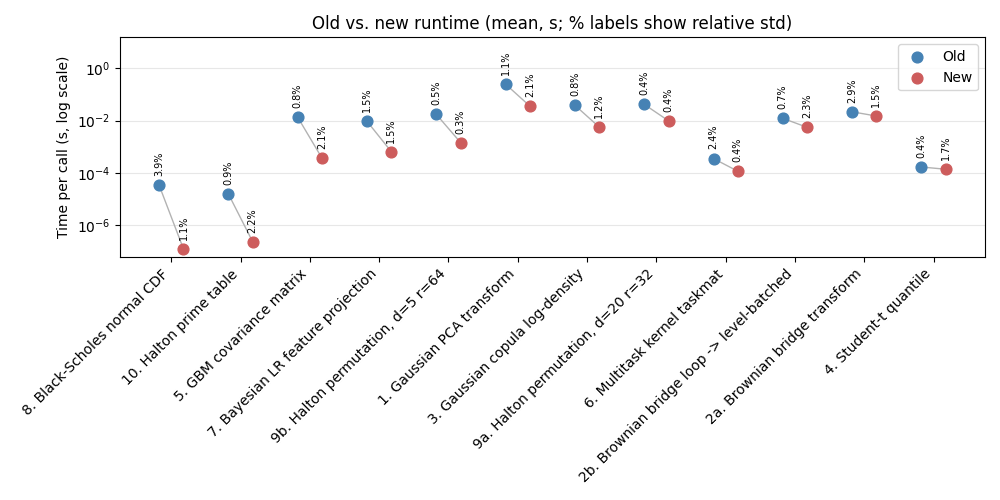

In [16]:
# Visualize mean runtime (log scale) for each component, old vs. new, as a dot/dumbbell
# plot rather than bars. Annotate relative std (%) as text: absolute std error bars are
# imperceptible here (relative std is only ~1-5% of the mean, collapsing to a fraction of
# a pixel on an axis spanning ~7 orders of magnitude).
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = sorted_summary_df.reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.35
x_old, x_new = x - width / 2, x + width / 2

for xo, xn, yo, yn in zip(x_old, x_new, plot_df['Old (s)'], plot_df['New (s)']):
    ax.plot([xo, xn], [yo, yn], color='gray', lw=1, alpha=0.6, zorder=1)

ax.scatter(x_old, plot_df['Old (s)'], label='Old', color='steelblue', s=60, zorder=3)
ax.scatter(x_new, plot_df['New (s)'], label='New', color='indianred', s=60, zorder=3)
ax.set_yscale('log')

def annotate_rel_std(xs, means, stds):
    for xi, mean, std in zip(xs, means, stds):
        pct = 100 * std / mean if mean > 0 else 0
        ax.annotate(f'{pct:.1f}%', (xi, mean), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=7, rotation=90)

annotate_rel_std(x_old, plot_df['Old (s)'], plot_df['Old Std (s)'])
annotate_rel_std(x_new, plot_df['New (s)'], plot_df['New Std (s)'])
ax.set_ylim(top=ax.get_ylim()[1] * 30)  # headroom for the rotated % labels

short_labels = plot_df['Component'].str.replace(r'\s*\([^)]+\.py\)$', '', regex=True)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_ylabel('Time per call (s, log scale)')
ax.set_title('Old vs. new runtime (mean, s; % labels show relative std)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Where these speedups show up in existing demos**, next time each is re-run:

- `demos/GBM/gbm_demo.ipynb`, `demos/GBM/gbm_examples.ipynb` -- GeometricBrownianMotion and BrownianMotion path generation (Sections 1, 2, and 5 above)
- `demos/brownian_bridge.ipynb` -- BrownianMotion with `decomp_type="BrownianBridge"` (Section 2)
- `demos/copula_examples.ipynb`, `demos/product_measure.ipynb` -- GaussianCopula (Section 3) and StudentTCopula (Section 4)
- `demos/vectorized_qmc.ipynb`, `demos/vectorized_qmc_bayes.ipynb` -- BayesianLRCoeffs (Section 7)
- `demos/pricing_options.ipynb`, `demos/asian-option-mlqmc.ipynb`, `demos/control_variates.ipynb` -- FinancialOption exact-value pricing (Section 8)
- `demos/linear-scrambled-halton.ipynb` -- Halton with the default `randomize="LMS DP"` (Section 9), once the proposed `qmctoolscl` fix ships; it's a dependency-level change, not a `qmcpy` release, so it won't take effect until `qmctoolscl` adopts it and `qmcpy`'s pin is updated
- `demos/linear-scrambled-halton.ipynb`, and every other demo that constructs a `Halton` or custom `DigitalNetAnyBases` -- the prime-table hoist (Section 10) is already merged into `qmcpy`, so it's active now, unconditionally

No existing demo currently exercises `KernelMultiTask` (Section 6); it is used internally by multi-output/multi-fidelity Bayesian cubature stopping criteria.

## Appendix: Other `scipy.stats` -> `scipy.special` swaps

The overhead-elimination trick above generalizes: any `scipy.stats.<dist>.{ppf,cdf,logcdf,...}` call has a `scipy.special` counterpart that skips the generic `rv_continuous`/`rv_discrete` dispatch (loc/scale handling, support-bounds validation, edge-case masking) and calls the underlying compiled routine directly.

| Instead of (`scipy.stats`, slow) | Use (`scipy.special`, fast) | Purpose | Used in QMCPy? |
|---|---|---|---|
| `norm.cdf` | `ndtr` | forward normal CDF | Yes -- `gaussian_copula.py`, `financial_option.py`, several stopping criteria (Sections 3, 8 above) |
| `norm.ppf` | `ndtri` | inverse normal CDF | Yes -- `gaussian.py`, `brownian_motion.py`, `johnsons_su.py`, several stopping criteria (Sections 1-2 above) |
| `norm.logcdf` | `log_ndtr` | log of normal CDF, numerically stable in the tails | Not currently used |
| `t.cdf` | `stdtr` | Student-t CDF | Yes -- `student_t_copula.py` |
| `t.ppf` | `stdtrit` | Student-t quantile (argument order flips to `stdtrit(df, p)`) | Yes -- `student_t.py`, `student_t_copula.py`, `cub_qmc_rep_student_t.py` (Section 4 above) |
| `chi2.cdf` | `chdtr` | chi-squared CDF | Not currently used |
| `chi2.ppf` | `chdtri` (note: `chdtri(df, 1 - q)`, since it inverts the *complemented* CDF -- `chdtriv` is a different function, the inverse with respect to degrees of freedom, not a quantile) | chi-squared quantile | Not currently used |
| `gamma.cdf` | `gammainc` (regularized lower incomplete gamma) | gamma CDF | Not currently used |
| `gamma.ppf` | `gammaincinv` (note: NOT `gammainccinv`, which inverts the *upper* incomplete gamma -- that's `gamma.isf`, not `gamma.ppf`) | gamma quantile | Not currently used |
| `beta.ppf` / `.cdf` | `betaincinv` / `betainc` | beta quantile/CDF | Not applicable -- `kumaraswamy.py` looks similar but is not a Beta distribution; it has its own closed-form quantile, `(1-(1-x)**(1/b))**(1/a)`, already faster than any `scipy` Beta call |
| `poisson.cdf` | `pdtr` | Poisson CDF | Not currently used |
| `binom.cdf` | `bdtr` | binomial CDF | Not currently used |
| `f.cdf` / `.ppf` | `fdtr` / `fdtri` | F-distribution CDF/quantile | Not currently used |

Sections 1-4 and 8 above benchmark the rows already used in QMCPy; the rest of the table is included for reference should a future distribution need one of these. (The chi2/gamma quantile rows above were originally wrong in an earlier draft of this table -- `chdtriv`/`gammainccinv` are not equivalents of `.ppf` at all; verified numerically, e.g. `gamma.ppf(0.1, 2) == gammaincinv(2, 0.1) == 0.531812`, not `gammainccinv(2, 0.1) == 3.889720`.)

## References

[1] Harris, C.R., Millman, K.J., van der Walt, S.J. et al. (2020). [Array programming with NumPy](https://www.nature.com/articles/s41586-020-2649-2). *Nature* 585, 357-362.

[2] Virtanen, P., Gommers, R., Oliphant, T.E. et al. (2020). [SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python](https://www.nature.com/articles/s41592-019-0686-2). *Nature Methods*, 17(3), 261-272.

[3] Dongarra, J.J., Du Croz, J., Duff, I.S., Hammarling, S. (1990). [A set of Level 3 Basic Linear Algebra Subprograms](https://dl.acm.org/doi/10.1145/77626.79170). *ACM Transactions on Mathematical Software*, 16(1), 1-17.

[4] Sorokin, A.G., Hickernell, F.J., Choi, S.-C.T., Rathinavel, J., Robbe, P., Jain, A. (2026). [QMCPy: A Python Framework for (Quasi-)Monte Carlo Algorithms](https://doi.org/10.21105/joss.09705). *Journal of Open Source Software*, 11(117), 9705.

[5] Paszke, A., Gross, S., Massa, F. et al. (2019). [PyTorch: An Imperative Style, High-Performance Deep Learning Library](https://papers.neurips.cc/paper/2019/hash/bdbca288fee7f92f2bfa9f7012727740-Abstract.html). *Advances in Neural Information Processing Systems 32 (NeurIPS 2019)*, 8024-8035.